# Shakespeare Vocabulary Analysis

Applies all species-richness estimators to the full Folger Shakespeare corpus and to each work individually.

**Pipeline:** `load_shakespeare` → `pipeline` (tokenise + count) → estimators  
**Sections:**
1. Frequency count distribution (replicates Table 5 format)
2. Richness estimates — all estimators on the full corpus
3. Rarefaction and extrapolation curve
4. Per-work analysis

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

from db import get_or_process, list_corpora
from estimators import (
    coverage_turing, coverage_chao_jost,
    good_turing_p0, chao1, ichao1, ace, jackknife1, jackknife2,
    breakaway,
)

DATA_DIR    = Path('../../data/shakespeare-dataset-main/text')
FIGURES_DIR = Path('../../figures')
FIGURES_DIR.mkdir(exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 0. Load corpus

In [3]:
wc_corpus, fc_corpus = get_or_process('full_corpus', DATA_DIR, loader='corpus')

n     = sum(wc_corpus.values())
S_obs = len(wc_corpus)
f1    = fc_corpus.get(1, 0)
f2    = fc_corpus.get(2, 0)

print(f'n  (tokens)             = {n:,}')
print(f'S_obs  (distinct words) = {S_obs:,}')
print(f'f1  (singletons)        = {f1:,}')
print(f'f2  (doubletons)        = {f2:,}')
print(f'Coverage  (Turing)      = {coverage_turing(fc_corpus):.4f}')
print(f'Coverage  (Chao-Jost)   = {coverage_chao_jost(fc_corpus):.4f}')

print()
print('--- Cached corpora ---')
print(list_corpora()[['name', 'n_tokens', 's_obs', 'coverage_turing', 'processed_at']])

[cache] loaded 'full_corpus' from database.
n  (tokens)             = 890,426
S_obs  (distinct words) = 25,700
f1  (singletons)        = 9,704
f2  (doubletons)        = 3,562
Coverage  (Turing)      = 0.9891
Coverage  (Chao-Jost)   = 0.9891

--- Cached corpora ---
                           name  n_tokens  s_obs  coverage_turing  \
0      A Midsummer Nights Dream     16385   2974         0.897650   
1      Alls Well That Ends Well     22852   3477         0.912699   
2          Antony And Cleopatra     24147   3882         0.906075   
3                As You Like It     21554   3229         0.917185   
4                    Coriolanus     27183   3977         0.916418   
5                     Cymbeline     27374   4206         0.914408   
6                        Hamlet     30095   4668         0.908025   
7               Henry Iv Part 1     24350   3809         0.911704   
8               Henry Iv Part 2     25791   4043         0.910705   
9                       Henry V     25718   4

---
## 1. Frequency count distribution

$f_k$ = number of distinct words that appear exactly $k$ times in the corpus.

In [4]:
# Table 5 format: x across the top, n_x in the row
max_x = 20
table_data = {k: fc_corpus.get(k, 0) for k in range(1, max_x + 1)}
df_table = pd.DataFrame([table_data])
df_table.index = ['$n_x$']
df_table.columns.name = '$x$'

print('Table: number of words appearing exactly x times')
df_table.style.format('{:,}')

Table: number of words appearing exactly x times


$x$,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
$n_x$,"9,704","3,562","2,050","1,408","1,028",759,620,475,415,393,292,264,217,231,192,176,165,143,144,146


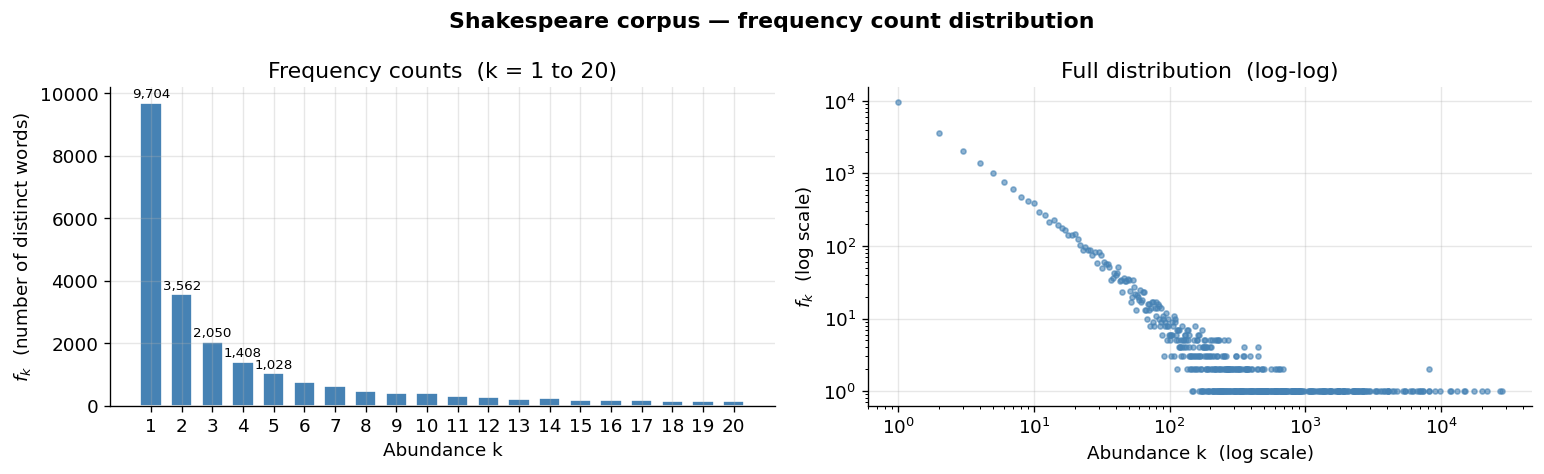

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left: bar chart for k = 1..20 ---
ks_bar  = list(range(1, 21))
fks_bar = [fc_corpus.get(k, 0) for k in ks_bar]

ax = axes[0]
ax.bar(ks_bar, fks_bar, color='steelblue', edgecolor='white', width=0.7)
ax.set_xlabel('Abundance k')
ax.set_ylabel('$f_k$  (number of distinct words)')
ax.set_title('Frequency counts  (k = 1 to 20)')
ax.set_xticks(ks_bar)
for k, v in zip(ks_bar[:5], fks_bar[:5]):
    ax.text(k, v + 60, f'{v:,}', ha='center', va='bottom', fontsize=8)

# --- Right: log-log of full distribution ---
ks_all  = np.array(sorted(fc_corpus.keys()))
fks_all = np.array([fc_corpus[k] for k in ks_all])

ax2 = axes[1]
ax2.loglog(ks_all, fks_all, 'o', color='steelblue', ms=3, alpha=0.6)
ax2.set_xlabel('Abundance k  (log scale)')
ax2.set_ylabel('$f_k$  (log scale)')
ax2.set_title('Full distribution  (log-log)')

plt.suptitle('Shakespeare corpus — frequency count distribution', fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'freq_counts.pdf', bbox_inches='tight')
plt.show()

---
## 2. Richness estimates on the full corpus

In [6]:
results = {}
results['S_obs']       = S_obs
results['Jackknife 1'] = jackknife1(fc_corpus)
results['Jackknife 2'] = jackknife2(fc_corpus)
results['Chao1']       = chao1(fc_corpus)
results['iChao1']      = ichao1(fc_corpus)
results['ACE']         = ace(fc_corpus, k_cutoff=10)

try:
    b = breakaway(fc_corpus)
    results['Breakaway'] = b['S_hat']
except Exception as e:
    print(f'Breakaway skipped: {e}')

df_est = pd.DataFrame({
    'Estimator':       list(results.keys()),
    'S_hat':           [round(v) for v in results.values()],
    'f0 estimate':     [round(v - S_obs) for v in results.values()],
    'S_hat / S_obs':   [round(v / S_obs, 3) for v in results.values()],
})
df_est.set_index('Estimator').style.format({'S_hat': '{:,}', 'f0 estimate': '{:,}'})

Breakaway skipped: Fitted beta0 = -0.5194 <= 0; cannot estimate f0. The rational model may be misspecified for this dataset.


,S_hat,f0 estimate,S_hat / S_obs
Estimator,,,
S_obs,"25,700",0,1.000000
Jackknife 1,"35,404","9,704",1.378000
Jackknife 2,"41,546","15,846",1.617000
Chao1,"38,918","13,218",1.514000
iChao1,"41,507","15,807",1.615000
ACE,"70,942","45,242",2.760000


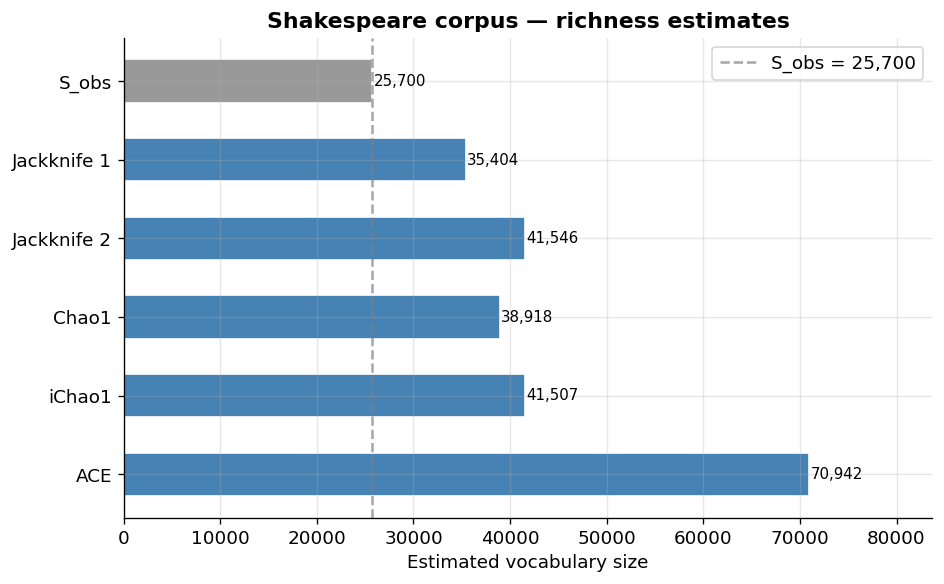

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

names  = list(results.keys())
values = [round(v) for v in results.values()]
colors = ['#999999'] + ['steelblue'] * (len(names) - 1)

# Reverse so S_obs is at top
bars = ax.barh(names[::-1], values[::-1], color=colors[::-1],
               edgecolor='white', height=0.55)

for bar, val in zip(bars, values[::-1]):
    ax.text(val + 150, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', ha='left', fontsize=9)

ax.axvline(S_obs, color='gray', linestyle='--', lw=1.5, alpha=0.7,
           label=f'S_obs = {S_obs:,}')
ax.set_xlabel('Estimated vocabulary size')
ax.set_title('Shakespeare corpus — richness estimates', fontweight='bold')
ax.set_xlim(0, max(values) * 1.18)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'estimator_comparison.pdf', bbox_inches='tight')
plt.show()

---
## 3. Rarefaction and extrapolation

**Rarefaction** ($m \leq n$): expected richness if only $m$ tokens had been sampled.  
Uses the approximation $E[S(m)] \approx S_{\rm obs} - \sum_k f_k \left(\frac{n-m}{n}\right)^k$.  

**Extrapolation** ($m > n$): projects forward using a Chao1-based geometric discovery rate.

In [8]:
def rarefaction(fc, m_values):
    """E[S(m)] for m <= n using the multinomial approximation."""
    n_tot   = sum(k * v for k, v in fc.items())
    S_obs_v = sum(fc.values())
    ks  = np.array(list(fc.keys()), dtype=float)
    fks = np.array(list(fc.values()), dtype=float)
    out = []
    for m in m_values:
        if m >= n_tot:
            out.append(float(S_obs_v))
        else:
            r = 1.0 - m / n_tot          # (n - m) / n
            out.append(S_obs_v - float(np.sum(fks * r ** ks)))
    return np.array(out)


def extrapolate(fc, extra_m):
    """E[S(m)] for m > n using a Chao1-based per-token discovery rate."""
    n_tot   = sum(k * v for k, v in fc.items())
    S_obs_v = sum(fc.values())
    f1_val  = fc.get(1, 0)
    f_hat_0 = max(chao1(fc) - S_obs_v, 1.0)
    p_new   = f1_val / (n_tot * f_hat_0 + f1_val)   # per-draw P(new species)
    out = []
    for m in extra_m:
        t     = m - n_tot
        extra = f_hat_0 * (1.0 - (1.0 - p_new) ** t)
        out.append(S_obs_v + extra)
    return np.array(out)

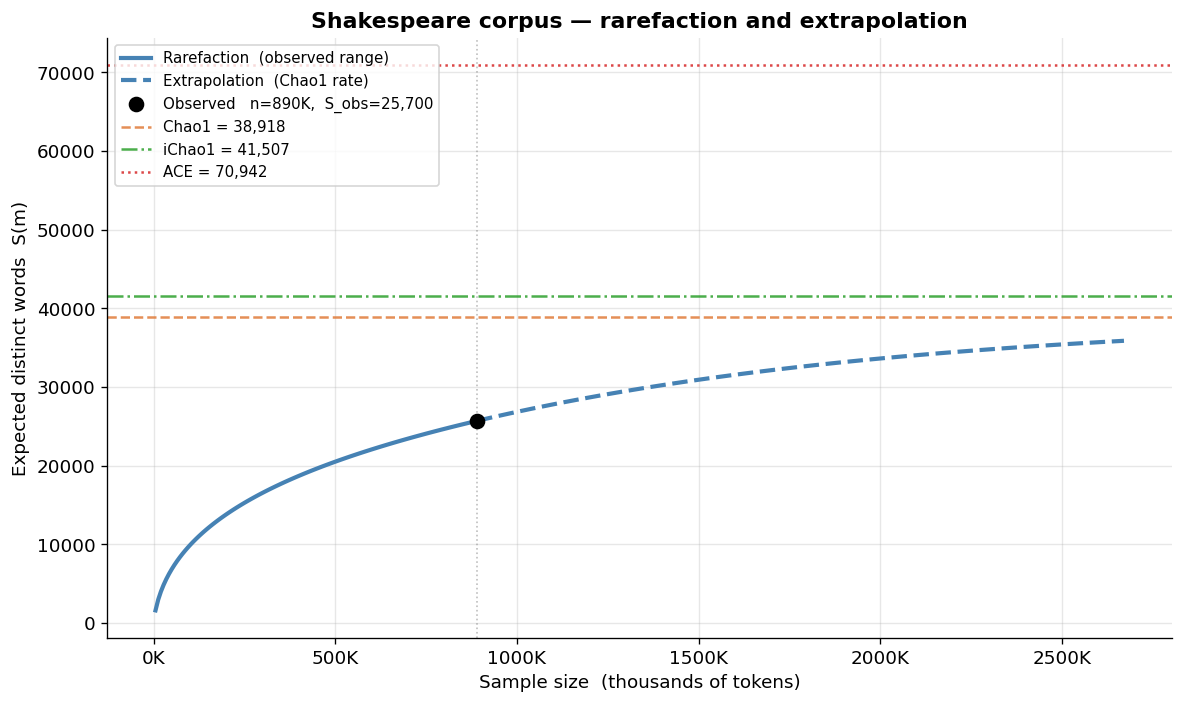

In [9]:
m_rare  = np.linspace(5_000, n, 120, dtype=int)
m_extra = np.linspace(n,     3 * n, 60, dtype=int)

S_rare  = rarefaction(fc_corpus, m_rare)
S_extra = extrapolate(fc_corpus, m_extra)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(m_rare  / 1e3, S_rare,  color='steelblue', lw=2.5,
        label='Rarefaction  (observed range)')
ax.plot(m_extra / 1e3, S_extra, color='steelblue', lw=2.5, linestyle='--',
        label='Extrapolation  (Chao1 rate)')

# Observed point
ax.scatter([n / 1e3], [S_obs], color='black', zorder=6, s=70,
           label=f'Observed   n={n/1e3:.0f}K,  S_obs={S_obs:,}')
ax.axvline(n / 1e3, color='gray', lw=1, linestyle=':', alpha=0.5)

# Asymptotic estimates
asym = [
    ('Chao1',  chao1(fc_corpus),  '#e07b39', '--'),
    ('iChao1', ichao1(fc_corpus), '#2ca02c', '-.'),
    ('ACE',    ace(fc_corpus),    '#d62728', ':'),
]
for lbl, val, col, ls in asym:
    ax.axhline(val, linestyle=ls, color=col, lw=1.5, alpha=0.85,
               label=f'{lbl} = {val:,.0f}')

ax.set_xlabel('Sample size  (thousands of tokens)')
ax.set_ylabel('Expected distinct words  S(m)')
ax.set_title('Shakespeare corpus — rarefaction and extrapolation', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rarefaction_extrapolation.pdf', bbox_inches='tight')
plt.show()

---
## 4. Per-work analysis

Apply Chao1 and iChao1 to each individual work, sorted by corpus size.

In [10]:
records = []
for path in sorted(DATA_DIR.glob('*.txt')):
    title = (path.stem
             .replace('_TXT_FolgerShakespeare', '')
             .replace('-', ' ')
             .title())
    wc, fc = get_or_process(title, path, loader='shakespeare', verbose=False)
    records.append({
        'Title':    title,
        'n':        sum(wc.values()),
        'S_obs':    len(wc),
        'Chao1':    round(chao1(fc)),
        'iChao1':   round(ichao1(fc)),
        'ACE':      round(ace(fc)),
        'Coverage': round(coverage_turing(fc), 3),
        'f1':       fc.get(1, 0),
    })

df_plays = (pd.DataFrame(records)
              .sort_values('n', ascending=False)
              .reset_index(drop=True))
df_plays.style.format({'n': '{:,}', 'S_obs': '{:,}', 'Chao1': '{:,}',
                       'iChao1': '{:,}', 'ACE': '{:,}', 'f1': '{:,}'})

,Title,n,S_obs,Chao1,iChao1,ACE,Coverage,f1
0,Hamlet,"30,095","4,668","10,109","11,013","17,900",0.908000,"2,768"
1,Richard Iii,"28,770","4,031","7,378","8,120","13,738",0.927000,"2,102"
2,Cymbeline,"27,374","4,206","8,309","9,067","15,303",0.914000,"2,343"
3,Coriolanus,"27,183","3,977","8,329","9,125","15,182",0.916000,"2,272"
4,Othello,"26,010","3,720","7,602","8,271","13,640",0.920000,"2,089"
5,Henry Iv Part 2,"25,791","4,043","8,306","9,094","15,133",0.911000,"2,303"
6,Henry V,"25,718","4,460","8,801","9,686","16,193",0.902000,"2,528"
7,Troilus And Cressida,"25,579","4,158","9,219","10,092","16,308",0.904000,"2,446"
8,King Lear,"25,566","4,108","9,006","9,806","16,184",0.906000,"2,394"
9,Henry Vi Part 2,"25,408","4,076","7,879","8,602","14,396",0.912000,"2,239"


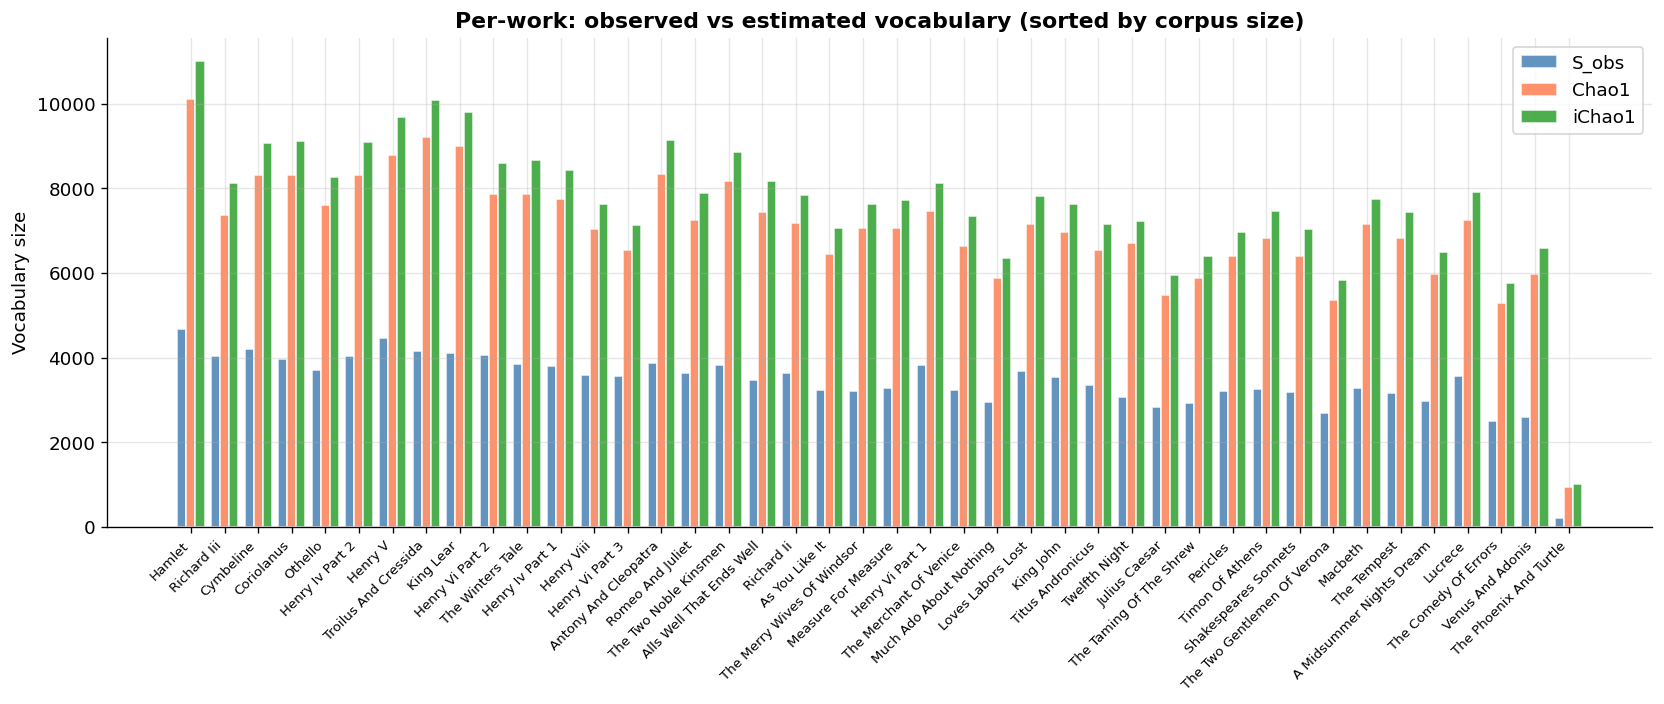

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df_plays))
w = 0.27

ax.bar(x - w, df_plays['S_obs'],  width=w, label='S_obs',
       color='steelblue', alpha=0.85, edgecolor='white')
ax.bar(x,     df_plays['Chao1'],  width=w, label='Chao1',
       color='coral',     alpha=0.85, edgecolor='white')
ax.bar(x + w, df_plays['iChao1'], width=w, label='iChao1',
       color='#2ca02c',   alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(df_plays['Title'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Vocabulary size')
ax.set_title('Per-work: observed vs estimated vocabulary (sorted by corpus size)',
             fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_work_estimates.pdf', bbox_inches='tight')
plt.show()

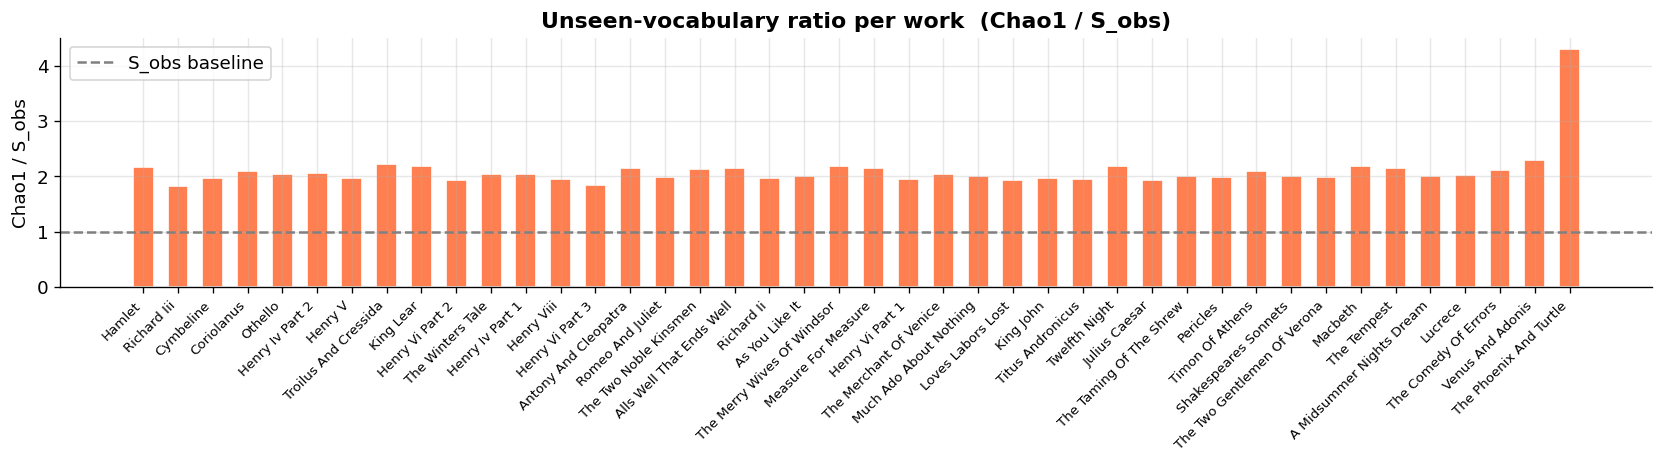

In [12]:
# Ratio Chao1 / S_obs per work — shows how much vocabulary is estimated to be unseen
fig, ax = plt.subplots(figsize=(14, 4))

ratio = df_plays['Chao1'] / df_plays['S_obs']
colors_ratio = ['coral' if r > 1.3 else 'steelblue' for r in ratio]

ax.bar(x, ratio, color=colors_ratio, edgecolor='white', width=0.6)
ax.axhline(1.0, color='gray', lw=1.5, linestyle='--', label='S_obs baseline')
ax.set_xticks(x)
ax.set_xticklabels(df_plays['Title'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Chao1 / S_obs')
ax.set_title('Unseen-vocabulary ratio per work  (Chao1 / S_obs)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_work_ratio.pdf', bbox_inches='tight')
plt.show()